<div class="alert alert-block alert-warning">
    
# Assignment

Welcome to your task 1 of the assignment! This notebook contains all the code and comments that you need to submit. The places where you need to edit are highlighted in red. Feel free to add in your own markdown for additional comments.

__Submission details: make sure you all your outputs have been generated. Submit this Jupyter Notebook.__

<b>Enter you student details below</b>

- <b>Student Name:</b> Wenxing Du
- <b>Student ID:</b> 30171857

<div class="alert alert-block alert-danger">

# Table of Contents

* [Task 1.1: Iterative weighted linear regression](#t1_1)
    
* [Task 1.2: Using non-linear features and learning rate decay for better classification](#t1_2)


<div class="alert alert-block alert-warning">

# Libraries 

Libraries are important as it saves us time from writing our own functions all the time such as graphing, or creating matrices. Brief library descriptions have been added for every library that we import. You may also check the official documentations for more details.

The required libraries are specified in this notebook for you.

In [63]:
import numpy as np
import matplotlib.pyplot as plt

<div class="alert alert-block alert-info">


# Before you begin

Ensure that you use __numpy__ or __torch__ efficiently instead of nested for loops to perform tensor multiplications. For example, if you are doing a 4x4 tensor multiplied with a 4x4 tensor using numpy, you should use np.matmul instead of 2 for loops. We highly recommend using __numpy__ for the entire task 1, as you will resuse some of the numpy code from the labs.


# Linear and logistic regression

In this task, you will be furthering your implementations with linear and logistic regression. This builds off your previous lab and aims to explore further possibilities with these models in both numerical estimation and classification tasks.

<div class="alert alert-block alert-info">

# Task 1.1 - Iterative weighted linear regression <a class="anchor" id="t1_1"></a>

In some problems, every data point might not have the same importance. Having weights associated to samples will provide us with a principal way to model such problems. Consider a data set in which each data point $(x_i, y_i)$, $x_i \in \mathbb{R}^n$, $y_i \in \mathbb{R}$ is associated with a weighting factor $0 < \alpha_i ≤ 1$. Define the loss of a linear model with parameters $w \in \mathbb{R}^n$ as the weighted sum-of-squares error:

$$ \mathcal{L}_{\mathrm{wSE}}(\boldsymbol{w})=\frac{1}{m}\sum_{i=1}^{m}\alpha_i(w^\top x_i - y_i)^2 $$

It can be shown that the optimal weights can be obtained as: 

$$ w^* = (X^\top A X)^{-1}X^\top A Y $$

Here, $X$ is a matrix of size $m × n$ where every row is one input sample (i.e., row $i$ in $X$ is $x_i$). Similarly, $Y$ is an m dimensional vector storing $y_i$ and $A$ is a diagonal matrix of size $m × m$ with $A[i, i] = \alpha_i$.

The purpose of this task is to train an iterative linear regression model that will weight the samples as the model is being trained. You need to develop the mechanism to weigh each sample as the model is being iteratively trained. Here, the diagonal matrix $A$ is updated by using the following equation:

$$ \hat{\alpha_i} = exp(-\sigma||y_i^{noisy} - \hat{y_i}||^2) $$

,where $\sigma$ is a hyperparemeter you can tune.

## (a) Developing a generic function for (weighted) linear regression

In [64]:
# This weighted least squares function can be used for both weighted least squares 
# or a vanilla linear regression model.

# "X,Y" inputs are required by the user
# The input "A" can be defaulted to an identity matrix which would result in a vanilla linear regression model
# The output will be the least square's calculated coefficients
# It is recommended you use the least squares formula which has been derived in the lectures when calculating your linear regression coefficients

def weighted_LS(X, Y, A=np.empty(0)):

# use WLS
    if A is None or A.size == 0:
        A = np.eye(X.shape[0])

    X_T_A_X_inv = np.linalg.inv(X.T @ A @ X)
    w_opt = X_T_A_X_inv @ X.T @ A @ Y



    return w_opt # Return optimal weight

# Function to calculate the error
# We are using least squares to calculate error (i.e., MSE)
# This is basically the euclidean distance for the error measure

def error_linear_model(X, w, Y):

    # Define MSE loss
    Y_pred = X @ w
    mse = np.mean((Y - Y_pred) ** 2)

    
    return mse

## (b) Iterative weighted linear regression

Load the data: _Task1_1.npz_

In [65]:
# Data was saved in a dictionary-liked form, where the keys are ('arr_0','arr_1')
# Load the values into correct variables according to the following mapping.
# X_trn <-- X_trn
# Y_trn <-- Y_trn
# X_val <-- X_val
# Y_val <-- Y_val

data = np.load("data/Task1_1.npz")

X_trn = data["X_trn"]
Y_trn = data["Y_trn"]
X_val = data["X_val"]
Y_val = data["Y_val"]

Visualise the train and validation data. Using a scatter plot, plot train data with red dots, validation data with blue dots. Remember to put title and x, y labels, legend for your plot.

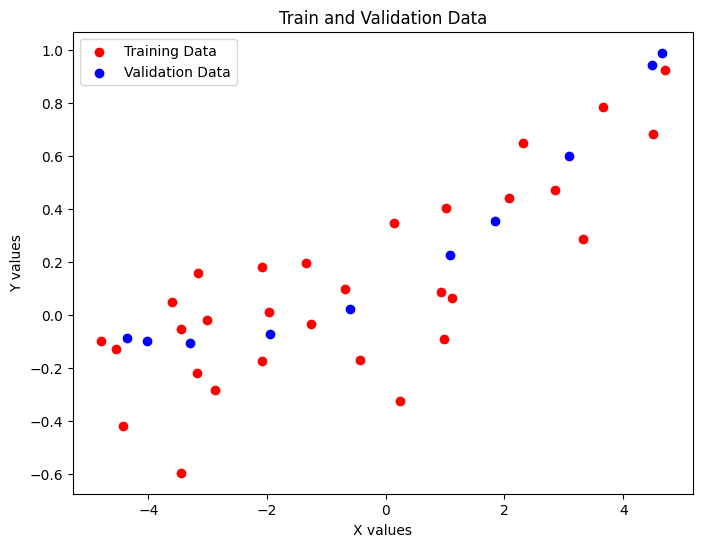

In [66]:
# Visualise the data. 

plt.figure(figsize=(8, 6))

plt.scatter(X_trn, Y_trn, color='red', label='Training Data')

plt.scatter(X_val, Y_val, color='blue', label='Validation Data')

plt.title('Train and Validation Data')
plt.xlabel('X values')
plt.ylabel('Y values')

plt.legend()

plt.show()

Since the data is non-linear, let's create non-linear features with the mapping: $ x_{aug} = [1, x, x^2, 1/x] $ for both train and validation data.

In [67]:
# Create non-linear features, do it for both train and validation data

def create_nonlinear_features(X):
    X_aug = np.column_stack((np.ones(X.shape), X, X**2, 1/X))
    return X_aug


X_trn_aug = create_nonlinear_features(X_trn)
X_val_aug = create_nonlinear_features(X_val)


print("Augmented training features:\n", X_trn_aug)
print("Augmented validation features:\n", X_val_aug)


Augmented training features:
 [[ 1.00000000e+00 -1.25459881e+00  1.57401818e+00 -7.97067549e-01]
 [ 1.00000000e+00  4.50714306e+00  2.03143386e+01  2.21870037e-01]
 [ 1.00000000e+00  2.31993942e+00  5.38211890e+00  4.31045739e-01]
 [ 1.00000000e+00  9.86584842e-01  9.73349650e-01  1.01359757e+00]
 [ 1.00000000e+00 -3.43981360e+00  1.18323176e+01 -2.90713427e-01]
 [ 1.00000000e+00 -3.44005480e+00  1.18339770e+01 -2.90693044e-01]
 [ 1.00000000e+00 -4.41916388e+00  1.95290094e+01 -2.26287150e-01]
 [ 1.00000000e+00  3.66176146e+00  1.34084970e+01  2.73092612e-01]
 [ 1.00000000e+00  1.01115012e+00  1.02242456e+00  9.88972837e-01]
 [ 1.00000000e+00  2.08072578e+00  4.32941976e+00  4.80601534e-01]
 [ 1.00000000e+00 -4.79415506e+00  2.29839227e+01 -2.08587329e-01]
 [ 1.00000000e+00  4.69909852e+00  2.20815269e+01  2.12806775e-01]
 [ 1.00000000e+00  3.32442641e+00  1.10518109e+01  3.00803771e-01]
 [ 1.00000000e+00 -2.87660889e+00  8.27487872e+00 -3.47631547e-01]
 [ 1.00000000e+00 -3.18175033e+0

Implement iterative weighted linear regression. You have to tune $\sigma$ and $max\_iter$ yourself.

In [68]:
# Iteratively fit the model
sigma = 17
A = np.eye(X_trn_aug.shape[0])

max_iter = 50 # Set the max. iteration
for num_iter in range(max_iter):
    # Fit a weighted linear regression model
    w_opt = weighted_LS(X_trn_aug, Y_trn, A)

    # Calculate MSE of the model on validation samples
    err_val = error_linear_model(X_val_aug, w_opt, Y_val)
    print(f"Error at iteration {num_iter}: {err_val:.4f}")
    
    # Obtain the weight of the train samples
    Y_trn_pred = X_trn_aug @ w_opt
    A = np.diag(np.exp(-sigma * np.square(Y_trn - Y_trn_pred)))

Error at iteration 0: 0.0080
Error at iteration 1: 0.0058
Error at iteration 2: 0.0052
Error at iteration 3: 0.0048
Error at iteration 4: 0.0047
Error at iteration 5: 0.0046
Error at iteration 6: 0.0046
Error at iteration 7: 0.0046
Error at iteration 8: 0.0046
Error at iteration 9: 0.0046
Error at iteration 10: 0.0046
Error at iteration 11: 0.0046
Error at iteration 12: 0.0046
Error at iteration 13: 0.0046
Error at iteration 14: 0.0046
Error at iteration 15: 0.0046
Error at iteration 16: 0.0046
Error at iteration 17: 0.0046
Error at iteration 18: 0.0046
Error at iteration 19: 0.0046
Error at iteration 20: 0.0046
Error at iteration 21: 0.0046
Error at iteration 22: 0.0046
Error at iteration 23: 0.0046
Error at iteration 24: 0.0046
Error at iteration 25: 0.0046
Error at iteration 26: 0.0046
Error at iteration 27: 0.0046
Error at iteration 28: 0.0046
Error at iteration 29: 0.0046
Error at iteration 30: 0.0046
Error at iteration 31: 0.0046
Error at iteration 32: 0.0046
Error at iteration 3

Now let's visualise the estimated **train data after being weighted**. Plot the original train samples in blue and the weighted samples after passing them into the model in red.

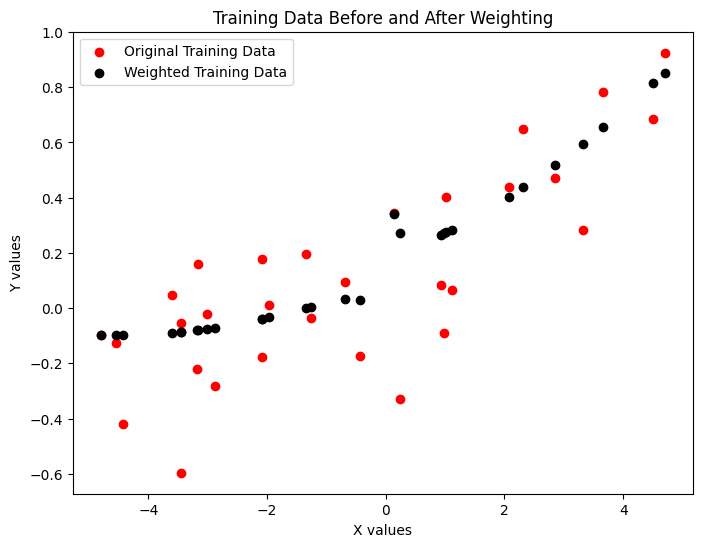

In [69]:
# Plot results.


plt.figure(figsize=(8, 6))


plt.scatter(X_trn, Y_trn, color='red', label='Original Training Data')


Y_trn_weighted_pred = X_trn_aug @ w_opt
plt.scatter(X_trn, Y_trn_weighted_pred, color='black', label='Weighted Training Data')


plt.title('Training Data Before and After Weighting')
plt.xlabel('X values')
plt.ylabel('Y values')


plt.legend()
plt.show()


<div class="alert alert-block alert-info">
    
# Task 1.2 - Using non-linear features and learning rate decay for better classification <a class="anchor" id="t1_2"></a>

You have been given a set of samples $x = (x_1,x_2)^\top \in \mathbb{R}^2$. In this task, you will apply the knowledge you learned from lab 2 to train a logistic model via Gradient Descent and try to improve the performance by implementing the decaying learning rate.

__Instructions:__

a. Copy any functions from Lab 2. The 3 functions you will need are: sigmoid(), predict(), compute_loss_and_grad()

b. Load and visualise data

c. Apply nonlinear transformation

d. Train the model using GD

e. Visualise the decision boundary

f. Write a decaying learning rate function

g. Train the model with decaying learning rate

## (a) Copy the required functions from lab 2 (if they were functional)

In [70]:
# Implement the sigmoid function

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

#result = sigmoid(1.6)
#print("Sigmoid(1.6) = ", result)

# Write a prediction function -> We predict the output class probability, NOT the class label (no 0,1 rounding)
def predict(X, w):
    
    x = X
    z = np.matmul(x, w)
    # probability
    y_hat = sigmoid(z)


    return y_hat



def compute_loss_and_grad(X, y, y_hat):

    
    eps = 1e-12

    # Compute the mean cross-entropy loss w.r.t. the parameters w (mean as defined in lecture)
    y = y.flatten()  # 

    a = y* np.log(y_hat + eps)
    b = (1 - y) * np.log(1 - y_hat + eps)
    loss = np.mean(-(a + b))

    # print("Shape of X:", X.shape)
    # print("Shape of y_hat:", y_hat.shape)
    # print("Shape of y:", y.shape)
    # print("Shape of (y_hat - y):", (y_hat - y).shape)  

    # Compute the gradient vector (mean over all samples as defined in lecture)
    #grad_vec = np.matmul((y_hat - y).transpose(),X) / len(y)
    #grad_vec = np.mean(np.matmul(X.T, (y_hat - y)), axis=0)
    grad_vec = np.matmul(X.T, (y_hat - y)) / len(y)  
    

    #print("Shape of grad_vec:", grad_vec.shape)  # should be (6,)


    # Return loss and gradient vector
    return loss, grad_vec

## (b) Load and visualise data

In [71]:
# Load numpy dataset from Task1_2.npz
loaded_data_task4 = np.load("data/Task1_2.npz")

# Create train and test datasets
# (X_train--> arr_0, X_test--> arr1_, Y_train_circle--> arr_2, Y_test_circle--> arr_3)
X_train = loaded_data_task4['arr_0']
X_test = loaded_data_task4['arr_1']
Y_train_circle = loaded_data_task4['arr_2']
Y_test_circle = loaded_data_task4['arr_3']

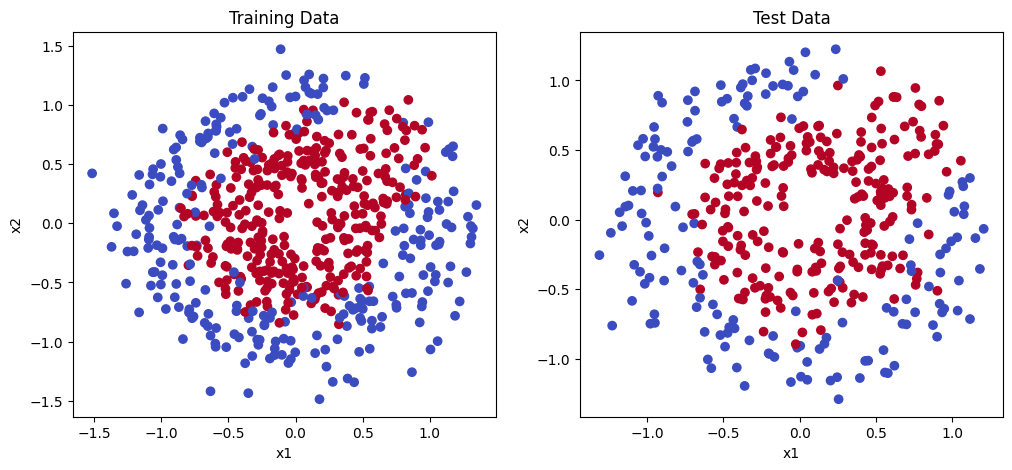

In [72]:
# Visualize non-linear features for both train and test data
# Create two plots side-by-side (Use subplots). Use scatter plots and show samples in different classes with different colours. The samples are 2-dimensional.

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(X_train[:, 0], X_train[:, 1], c=Y_train_circle, cmap='coolwarm', label='Train Data')
plt.title('Training Data')
plt.xlabel('x1')
plt.ylabel('x2')

plt.subplot(1, 2, 2)
plt.scatter(X_test[:, 0], X_test[:, 1], c=Y_test_circle, cmap='coolwarm', label='Test Data')
plt.title('Test Data')
plt.xlabel('x1')
plt.ylabel('x2')

plt.show()

## (c) Apply nonlinear transformation

Let's map the samples with $x_{trans}=[x_1, x_2, x_1^2, x_2^2, x_1x_2, 1]$

In [74]:
# Apply nonlinear mapping

def apply_nonlinear_transformation(X):
    X_aug = np.column_stack((X[:, 0], X[:, 1], X[:, 0]**2, X[:, 1]**2, X[:, 0] * X[:, 1], np.ones(X.shape[0])))
    return X_aug

X_train_aug = apply_nonlinear_transformation(X_train)
X_test_aug = apply_nonlinear_transformation(X_test)



In [75]:
print("Shape of X_train_aug:", X_train_aug.shape)


Shape of X_train_aug: (600, 6)


## (d) Train the model using GD

In [108]:
# Set a random seed (Do not change!) ==============
np.random.seed(0)
# =================================================

lr=1.0 # Set the learning to be 1.0
num_epochs = 10000 # Train for 10000 epochs

loss = np.zeros(num_epochs)
#theta = np.random.randn(X_train_aug.shape[1]) # Initialise theta
theta = np.random.randn(X_train_aug.shape[1]) * 0.01

for ep in range(num_epochs):

    # Apply gradient descent here and record loss

    y_hat = predict(X_train_aug, theta)
    
    
    loss[ep], grad = compute_loss_and_grad(X_train_aug, Y_train_circle, y_hat)

    #print("Shape of theta:", theta.shape)
    #print("Shape of grad:", grad.shape)
    
    
    theta -= lr * grad
    #theta = np.random.randn(X_train_aug.shape[1]) * 0.01  # Initialise theta
   

# Evaluate the classification accuracy for training and test data
train_accuracy = np.mean((predict(X_train_aug, theta) >= 0.5) == Y_train_circle)
test_accuracy = np.mean((predict(X_test_aug, theta) >= 0.5) == Y_test_circle)



print("Training accuracy: {:.3f}".format(train_accuracy))
print("Test accuracy: {:.3f}".format(test_accuracy))

Training accuracy: 0.507
Test accuracy: 0.520



## (e) Visualise the Decision Boundary

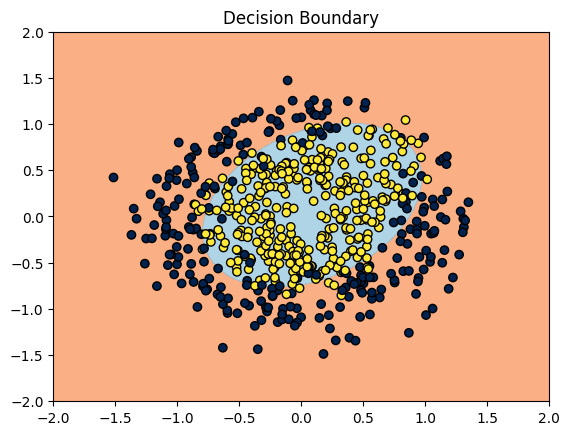

In [109]:
# You can use meshgrid and linearly spaced points to plot the decision boundary
# You may choose other ways to plot the decision boundary

xx=np.linspace(-2,2,1000)
yy=np.linspace(-2,2,1000)
[X2,Y2]=np.meshgrid(xx,yy)

grid = np.c_[X2.ravel(), Y2.ravel()]
grid_aug = apply_nonlinear_transformation(grid)
Z = predict(grid_aug, theta).reshape(X2.shape)

plt.contourf(X2, Y2, Z, levels=[0, 0.5, 1], cmap='RdYlBu', alpha=0.7)
plt.scatter(X_train[:, 0], X_train[:, 1], c=Y_train_circle, cmap='cividis', edgecolors='k')
plt.title('Decision Boundary')
plt.show()

## (f) Write a decaying learning rate function

In [110]:
# Write a simple function to decrease current learning rate by 0.1% in each epoch
#def decaying_lr(lr):
    
    
#    return ??? # return the new learning rate

def decaying_lr(lr, alpha=0.001):
    return lr * (1 - alpha)


## (g) Train the model with decaying learning rate

In [111]:
# Set a random seed (Do not change!)
np.random.seed(0)

# Set initial learning rate to 1.0
lr = 1.0
num_epochs = 10000  # Train for 10000 epochs

loss = np.zeros(num_epochs)
theta = np.random.randn(X_train_aug.shape[1]) * 0.01  # Initialise theta

alpha = 0.001  

for ep in range(num_epochs):
    # Apply gradient descent here and record loss
    y_hat = predict(X_train_aug, theta)
    loss[ep], grad = compute_loss_and_grad(X_train_aug, Y_train_circle, y_hat)
    
    # Apply learning rate decay here
    lr = decaying_lr(lr, alpha)
    
    print(f"Epoch {ep}: Learning rate {lr}") 
    
    # Update theta
    theta -= lr * grad

# Evaluate the classification accuracy for training and test data
train_accuracy = np.mean((predict(X_train_aug, theta) >= 0.5) == Y_train_circle)
test_accuracy = np.mean((predict(X_test_aug, theta) >= 0.5) == Y_test_circle)

print("Training accuracy: {:.3f}".format(train_accuracy))
print("Test accuracy: {:.3f}".format(test_accuracy))


Epoch 0: Learning rate 0.999
Epoch 1: Learning rate 0.998001
Epoch 2: Learning rate 0.997002999
Epoch 3: Learning rate 0.996005996001
Epoch 4: Learning rate 0.995009990004999
Epoch 5: Learning rate 0.994014980014994
Epoch 6: Learning rate 0.993020965034979
Epoch 7: Learning rate 0.9920279440699441
Epoch 8: Learning rate 0.9910359161258742
Epoch 9: Learning rate 0.9900448802097482
Epoch 10: Learning rate 0.9890548353295385
Epoch 11: Learning rate 0.988065780494209
Epoch 12: Learning rate 0.9870777147137147
Epoch 13: Learning rate 0.986090636999001
Epoch 14: Learning rate 0.9851045463620021
Epoch 15: Learning rate 0.98411944181564
Epoch 16: Learning rate 0.9831353223738244
Epoch 17: Learning rate 0.9821521870514506
Epoch 18: Learning rate 0.9811700348643991
Epoch 19: Learning rate 0.9801888648295347
Epoch 20: Learning rate 0.9792086759647052
Epoch 21: Learning rate 0.9782294672887405
Epoch 22: Learning rate 0.9772512378214517
Epoch 23: Learning rate 0.9762739865836303
Epoch 24: Learning 

<div class="alert alert-block alert-success">

## 1.3 Discussion  <a class="anchor" id="t1_3"></a>

1. What do you notice about the outliers for the implementations weighted linear regression?
    
2. In what situations, you may want to use higher dimensional features? (Answer in terms of decision boundary)

3. Why is it important to augment the bias term for this non-linear transformation? What does it actually do to the decision boundary?

4. What is the aim of applying decay in learning rate? 
    
## Answer
    
1. In weighted linear regression, outliers are usually given smaller weights. This means that these outliers have less impact on the model, and the model will focus more on those data points that better fit the overall pattern. This method helps reduce the interference of outliers on model fitting, thereby making the model more robust.

2. Some data points may not be directly separated by straight lines. After introducing these nonlinear characteristics (higher order terms, etc.) The model can fit more complex decision boundaries in high-dimensional space, such as elliptical boundaries instead of just a straight line. This can help the model classify or fit the data better

3. Without the bias term, the decision boundary is always forced through the origin, which is unreasonable in most cases. By introducing bias terms, the model can better adjust the position of the decision boundary, making the classification results more accurate.

4. In the early stages of training, a larger learning rate helps to quickly find better parameters. When approaching the optimal solution, reducing the learning rate can prevent the model from missing the optimal point, thereby allowing more fine-grained parameter adjustments to obtain better performance